In [8]:
import pandas as pd
# Load dataset
df = pd.read_csv("demand_forecasting.csv")
# Show basic info
print(df.shape)
print(df.head())
print(df.columns)
print(df.info())

(76000, 16)
         Date Store ID Product ID     Category Region  Inventory Level  \
0  01-01-2022     S001      P0001  Electronics  North              195   
1  01-01-2022     S001      P0002     Clothing  North              117   
2  01-01-2022     S001      P0003     Clothing  North              247   
3  01-01-2022     S001      P0004  Electronics  North              139   
4  01-01-2022     S001      P0005    Groceries  North              152   

   Units Sold  Units Ordered  Price  Discount Weather Condition  Promotion  \
0         102            252  72.72         5             Snowy          0   
1         117            249  80.16        15             Snowy          1   
2         114            612  62.94        10             Snowy          1   
3          45            102  87.63        10             Snowy          0   
4          65            271  54.41         0             Snowy          0   

   Competitor Pricing Seasonality  Epidemic  Demand  
0               85.7

In [9]:
df.columns = df.columns.str.strip().str.replace(" ", "_")

In [10]:
df.isnull().sum()

Date                  0
Store_ID              0
Product_ID            0
Category              0
Region                0
Inventory_Level       0
Units_Sold            0
Units_Ordered         0
Price                 0
Discount              0
Weather_Condition     0
Promotion             0
Competitor_Pricing    0
Seasonality           0
Epidemic              0
Demand                0
dtype: int64

In [11]:
df.select_dtypes(include="object").columns

Index(['Date', 'Store_ID', 'Product_ID', 'Category', 'Region',
       'Weather_Condition', 'Seasonality'],
      dtype='object')

In [12]:
#Feature engineering begins
df = df.drop(columns=["Date"])

In [13]:
df = df.reset_index(drop=True)
df["Time_Step"] = range(len(df))

In [14]:
df.columns

Index(['Store_ID', 'Product_ID', 'Category', 'Region', 'Inventory_Level',
       'Units_Sold', 'Units_Ordered', 'Price', 'Discount', 'Weather_Condition',
       'Promotion', 'Competitor_Pricing', 'Seasonality', 'Epidemic', 'Demand',
       'Time_Step'],
      dtype='object')

In [15]:
df["Time_Step"].head()

0    0
1    1
2    2
3    3
4    4
Name: Time_Step, dtype: int64

In [16]:
X = df.drop(columns=["Demand"])
y = df["Demand"]

print(X.shape, y.shape)
# We are telling the model:

# X = inputs (all factors affecting demand)
# y = target (Demand prediction)

(76000, 15) (76000,)


In [17]:
#encoding categorical columns
from sklearn.preprocessing import LabelEncoder
cat_cols = X.select_dtypes(include="object").columns
le = LabelEncoder()
for col in cat_cols:
    X[col] = le.fit_transform(X[col])

In [19]:
#Scaling 
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

In [20]:
print(X_scaled.shape)

(76000, 15)


In [21]:
print(X_scaled.min(), X_scaled.max())

0.0 1.0


In [22]:
#define wind size
import numpy as np
X_data = X_scaled
y_data = y.values
#sequence  length
seq_length = 10
#create sequence
X_seq = []
y_seq = []

for i in range(seq_length, len(X_data)):
    X_seq.append(X_data[i-seq_length:i])
    y_seq.append(y_data[i])

X_seq = np.array(X_seq)
y_seq = np.array(y_seq)

print(X_seq.shape)
print(y_seq.shape)

(75990, 10, 15)
(75990,)


In [23]:
#before model building,splitting the data
split = int(0.8 * len(X_seq))

X_train = X_seq[:split]
X_test = X_seq[split:]

y_train = y_seq[:split]
y_test = y_seq[split:]

print(X_train.shape, X_test.shape)
print(y_train.shape, y_test.shape)

(60792, 10, 15) (15198, 10, 15)
(60792,) (15198,)


In [24]:
#import model

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

In [25]:
#Build model
model = Sequential()

model.add(LSTM(64, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(Dropout(0.2))

model.add(LSTM(64, return_sequences=False))
model.add(Dropout(0.2))

model.add(Dense(32))
model.add(Dense(1))

In [ ]:
#Compile
model.compile(optimizer='adam', loss='mse')

In [27]:
#Train model
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/10
1900/1900 [==============================] - 61s 29ms/step - loss: 2555.5850 - val_loss: 1707.9050
Epoch 2/10
1900/1900 [==============================] - 51s 27ms/step - loss: 1989.2316 - val_loss: 1730.9485
Epoch 3/10
1900/1900 [==============================] - 53s 28ms/step - loss: 1922.9659 - val_loss: 1641.7958
Epoch 4/10
1900/1900 [==============================] - 54s 29ms/step - loss: 1858.3151 - val_loss: 1596.6661
Epoch 5/10
1900/1900 [==============================] - 48s 26ms/step - loss: 1776.2357 - val_loss: 1507.5092
Epoch 6/10
1900/1900 [==============================] - 53s 28ms/step - loss: 1691.1177 - val_loss: 1437.5383
Epoch 7/10
1900/1900 [==============================] - 55s 29ms/step - loss: 1626.5314 - val_loss: 1385.3157
Epoch 8/10
1900/1900 [==============================] - 54s 29ms/step - loss: 1583.1989 - val_loss: 1375.9978
Epoch 9/10
1900/1900 [==============================] - 89s 47ms/step - loss: 1552.3438 - val_loss: 1360.9479
Epoch 10/1

In [28]:
model.save("lstm_model.h5")

d:\Demand Forecasting System\venv\lib\site-packages\keras\src\engine\training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [29]:
from tensorflow.keras.models import load_model

m = load_model("lstm_model.h5")
print("Model loaded successfully")

Model loaded successfully


In [30]:
#make predictions
y_pred = model.predict(X_test)

475/475 [==============================] - 7s 11ms/step


In [31]:
#ensure shape is correct
y_test = y_test.reshape(-1, 1)
y_pred = y_pred.reshape(-1, 1)

In [32]:
#Reverse Scaling
y_test_final = y_test
y_pred_final = y_pred

In [33]:
#Model Evaluation
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test_final, y_pred_final))
mae = mean_absolute_error(y_test_final, y_pred_final)

print("RMSE:", rmse)
print("MAE:", mae)

RMSE: 36.72258789783289
MAE: 28.3154354095459


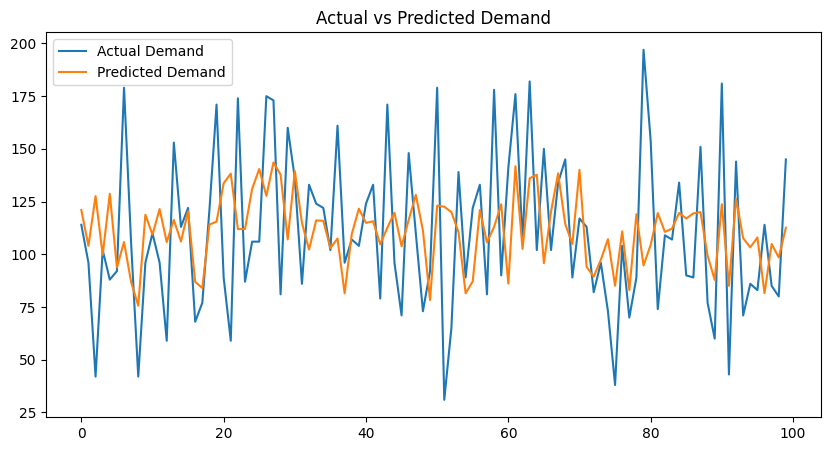

In [34]:
#Visualization
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(y_test_final[:100], label="Actual Demand")
plt.plot(y_pred_final[:100], label="Predicted Demand")
plt.legend()
plt.title("Actual vs Predicted Demand")
plt.show()